## 1. Configuração dos experimentos

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

## 2. Carregamento e preparação dos dados

In [3]:
treino = pd.read_csv('../../dataset/treino.csv')
teste = pd.read_csv('../../dataset/teste.csv')
validacao = pd.read_csv('../../dataset/validacao.csv')

treino = treino.replace({'b': 0, 'o': -1, 'x': 1})
teste = teste.replace({'b': 0, 'o': -1, 'x': 1})
validacao = validacao.replace({'b': 0, 'o': -1, 'x': 1})

In [4]:
x_treino = treino.drop(columns=['classe'])
y_treino = treino['classe']
x_teste = teste.drop(columns=['classe'])
y_teste = teste['classe']
x_validacao = validacao.drop(columns=['classe'])
y_validacao = validacao['classe']

## 3. Treinamento e validação da Random Forest

In [5]:
resultados = {}
modelos = {}
predicoes = {}
dados_treino = {}

def avaliar(nome, modelo, x_tr=x_treino, y_tr=y_treino):
    modelo.fit(x_tr, y_tr)
    y_pred = modelo.predict(x_validacao)
    resultados[nome] = {
        'acuracia': accuracy_score(y_validacao, y_pred),
        'precisao': precision_score(y_validacao, y_pred, average='macro', zero_division=0),
        'recall':   recall_score(y_validacao, y_pred, average='macro', zero_division=0),
        'f1':       f1_score(y_validacao, y_pred, average='macro', zero_division=0),
    }
    modelos[nome] = modelo
    predicoes[nome] = y_pred
    dados_treino[nome] = (x_tr, y_tr)
    return modelo, y_pred

In [6]:
# Com oversampling (treino_bal)
avaliar('rf_1',
        RandomForestClassifier(n_estimators=50,
                               class_weight='balanced',
                               random_state=42)
        )

(RandomForestClassifier(class_weight='balanced', n_estimators=50,
                        random_state=42),
 array(['X venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'X venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'Tem jogo',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'X venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'O venceu', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'X venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'X venceu', 'O venceu', 'Tem jogo',
        

In [7]:
avaliar('rf_2',
        RandomForestClassifier(n_estimators=100,
                               class_weight='balanced',
                               random_state=42)
        )

(RandomForestClassifier(class_weight='balanced', random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'X venceu', 'O venceu', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'Tem jogo',
        'O venceu', 'O venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'X venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'O venceu', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'X venceu', 'Tem jogo', 'X venceu', 'O venceu', 'Tem jogo',
        'Tem jogo', 'O venceu', 'X venceu', 'O ve

In [8]:
avaliar('rf_3',
        RandomForestClassifier(n_estimators=200,
                               class_weight='balanced',
                               random_state=42)
        )

(RandomForestClassifier(class_weight='balanced', n_estimators=200,
                        random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'Tem jogo',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'X venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'O venceu', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'X venceu', 'O venceu', 'Tem jogo',
       

In [9]:
avaliar('rf_4',
        RandomForestClassifier(n_estimators=100,
                               max_depth=5,
                               class_weight='balanced',
                               random_state=42)
        )

(RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42),
 array(['X venceu', 'Tem jogo', 'X venceu', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu', 'X venceu',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'X venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'O venceu', 'O venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'X venceu', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'X venceu', 'O venceu', 'Tem jogo',
        'Tem jogo', 'O venceu', 'X v

In [10]:
avaliar('rf_5',
        RandomForestClassifier(n_estimators=100,
                               max_depth=10,
                               class_weight='balanced',
                               random_state=42)
        )

(RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'X venceu', 'O venceu', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'Tem jogo',
        'O venceu', 'O venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'O venceu', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'X venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'X venceu', 'O venceu', 'Tem jogo',
        'Tem jogo', 'O venceu', 'X 

In [11]:
def graficos(nome, y_real, y_pred, conjunto):
    modelo = modelos[nome]
    rotulo = f"{nome} ({conjunto})"

    # 1) Matriz de confusão
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_real, y_pred, cmap='Blues', ax=ax)
    ax.set_title(f"Matriz de confusão – {rotulo}")
    plt.show()

    # 2) Quantidade por classe: real vs predito
    classes = np.unique(np.concatenate([np.asarray(y_real), y_pred]))
    real = [np.sum(np.asarray(y_real) == c) for c in classes]
    pred = [np.sum(y_pred == c) for c in classes]
    x = np.arange(len(classes))

    plt.figure(figsize=(8, 5))
    plt.bar(x - 0.2, real, width=0.4, label="Real", color="blue", alpha=0.7)
    plt.bar(x + 0.2, pred, width=0.4, label="Predito", color="red", alpha=0.7)
    plt.xticks(x, classes)
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.title(f"Distribuição das classes – {rotulo}")
    plt.legend()
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.show()

    # 3) Importância dos atributos (casas do tabuleiro)
    importancias = pd.Series(modelo.feature_importances_, index=x_treino.columns).sort_values()
    plt.figure(figsize=(8, 5))
    plt.barh(importancias.index, importancias.values, color="green", alpha=0.7)
    plt.xlabel("Importância")
    plt.title(f"Importância das casas – {rotulo}")
    plt.grid(True, axis="x", linestyle="--", alpha=0.6)
    plt.show()

    # Relatório por classe
    print(f"Relatório – {rotulo}")
    print(classification_report(y_real, y_pred, zero_division=0))

    # Estrutura da floresta
    print("Número de árvores:", modelo.n_estimators)
    print("Profundidade máxima:", modelo.max_depth)
    profundidades = [arvore.get_depth() for arvore in modelo.estimators_]
    print("Profundidade média real das árvores:", np.mean(profundidades))

### 3.1 Justificativa dos parâmetros

*(a escrever)*

### 3.2 Análise de overfitting

Análise de overfitting
      f1_treino  f1_validacao  diferenca
rf_1     0.9982        0.7016     0.2966
rf_2     1.0000        0.7353     0.2647
rf_3     1.0000        0.7508     0.2492
rf_4     0.8006        0.6627     0.1379
rf_5     1.0000        0.7007     0.2993


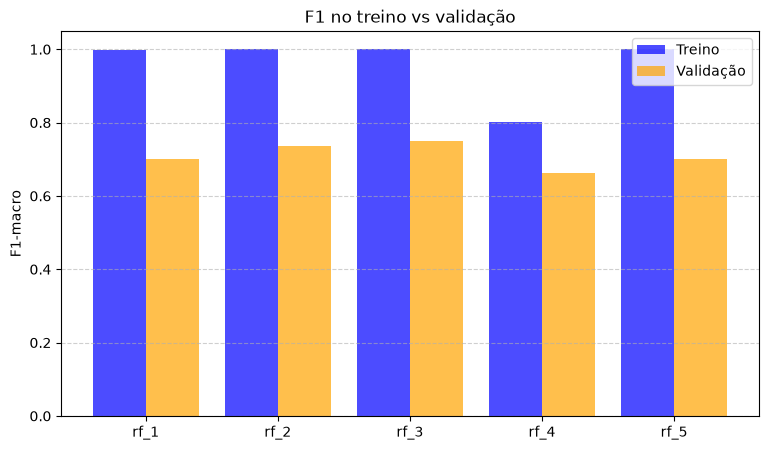

In [12]:
# Análise de overfitting: F1 no treino vs F1 na validação
overfitting = {}
for nome, modelo in modelos.items():
    x_tr, y_tr = dados_treino[nome]
    y_pred_treino = modelo.predict(x_tr)
    f1_treino = f1_score(y_tr, y_pred_treino, average='macro', zero_division=0)
    f1_val = resultados[nome]['f1']
    overfitting[nome] = {
        'f1_treino': f1_treino,
        'f1_validacao': f1_val,
        'diferenca': f1_treino - f1_val,
    }

df_overfitting = pd.DataFrame(overfitting).T.round(4)
print('Análise de overfitting')
print(df_overfitting)

x = np.arange(len(df_overfitting))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, df_overfitting['f1_treino'], width=0.4, label="Treino", color="blue", alpha=0.7)
plt.bar(x + 0.2, df_overfitting['f1_validacao'], width=0.4, label="Validação", color="orange", alpha=0.7)
plt.xticks(x, df_overfitting.index)
plt.ylabel("F1-macro")
plt.ylim(0, 1.05)
plt.title("F1 no treino vs validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

### 3.3 Interpretação dos resultados de overfitting

*(a escrever)*

## 4. Resultados dos experimentos

### 4.1 Comparação entre as abordagens

-----
Tabela de resultados
      acuracia  precisao  recall      f1
rf_3    0.8280    0.8712  0.7167  0.7508
rf_2    0.8065    0.8600  0.7000  0.7353
rf_1    0.7634    0.8203  0.6667  0.7016
rf_5    0.7634    0.8240  0.6667  0.7007
rf_4    0.6237    0.7156  0.6333  0.6627
-----


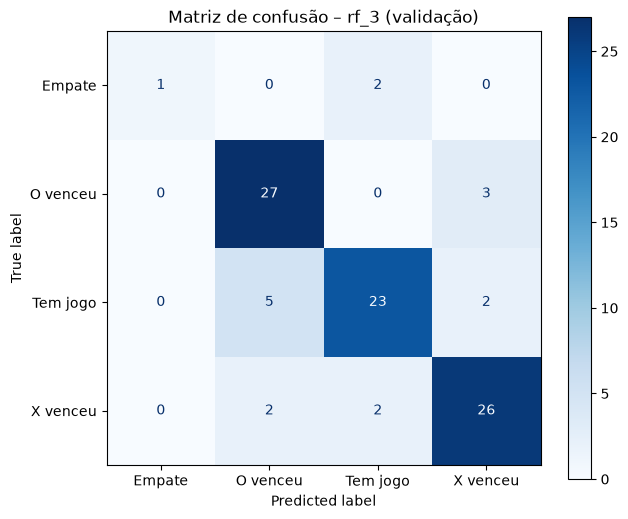

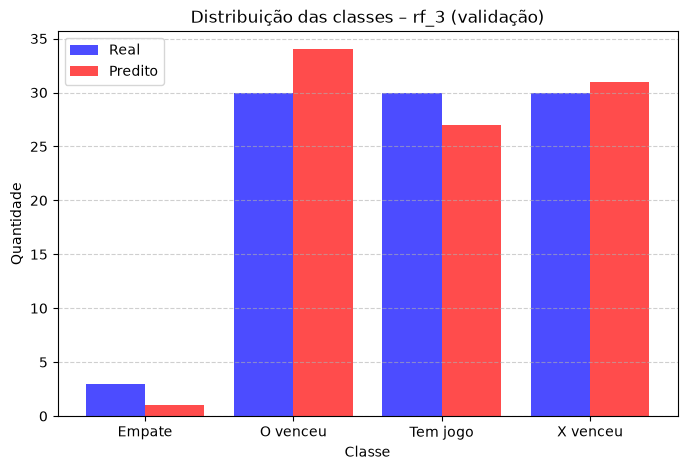

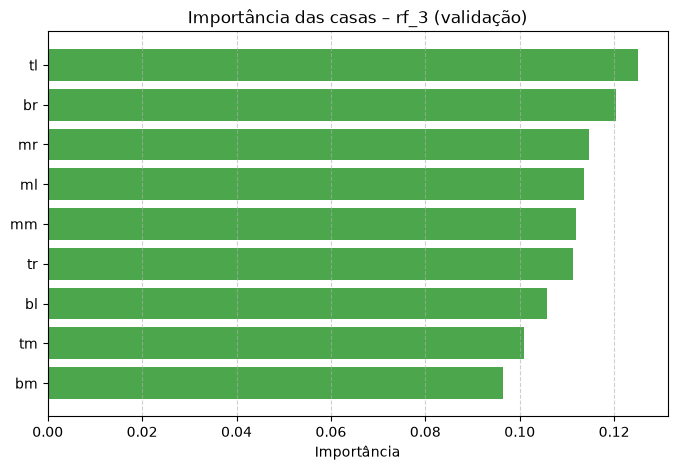

Relatório – rf_3 (validação)
              precision    recall  f1-score   support

      Empate       1.00      0.33      0.50         3
    O venceu       0.79      0.90      0.84        30
    Tem jogo       0.85      0.77      0.81        30
    X venceu       0.84      0.87      0.85        30

    accuracy                           0.83        93
   macro avg       0.87      0.72      0.75        93
weighted avg       0.83      0.83      0.82        93

Número de árvores: 200
Profundidade máxima: None
Profundidade média real das árvores: 11.235


In [13]:
print("-----")
print('Tabela de resultados')
df = pd.DataFrame(resultados).T.round(4)
print(df.sort_values('f1', ascending=False))
print('-----')

melhor = df['f1'].idxmax()
graficos(melhor, y_validacao, predicoes[melhor], 'validação')

### 4.2 Gráfico comparativo

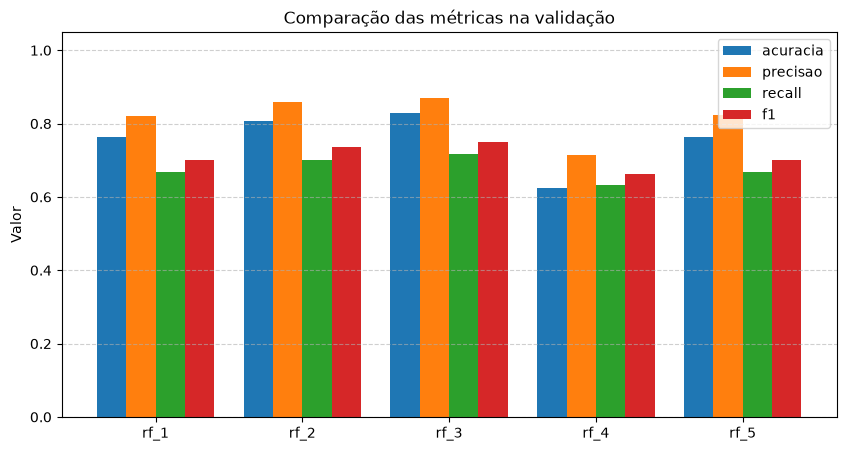

In [14]:
# Comparação das 4 métricas na validação para cada modelo
metricas = ['acuracia', 'precisao', 'recall', 'f1']
x = np.arange(len(df))
largura = 0.2

plt.figure(figsize=(10, 5))
for i, metrica in enumerate(metricas):
    plt.bar(x + (i - 1.5) * largura, df[metrica], width=largura, label=metrica)
plt.xticks(x, df.index)
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.title("Comparação das métricas na validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

### 4.3 Avaliação no conjunto de teste

-----
Resultado final no teste – rf_3
acuracia    0.7527
precisao    0.5829
recall      0.5833
f1          0.5741
dtype: float64
-----


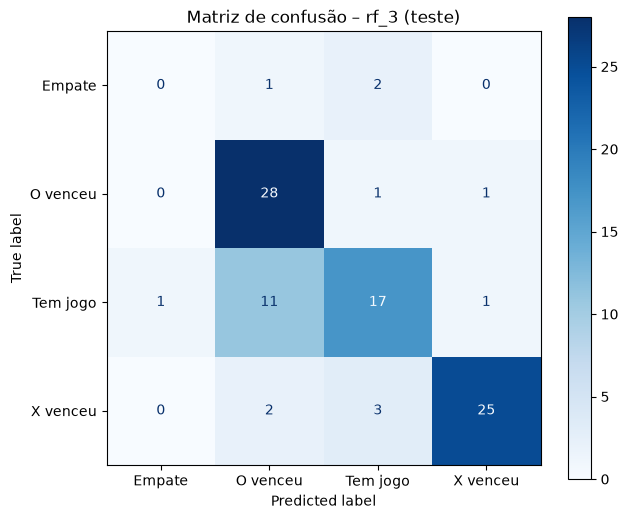

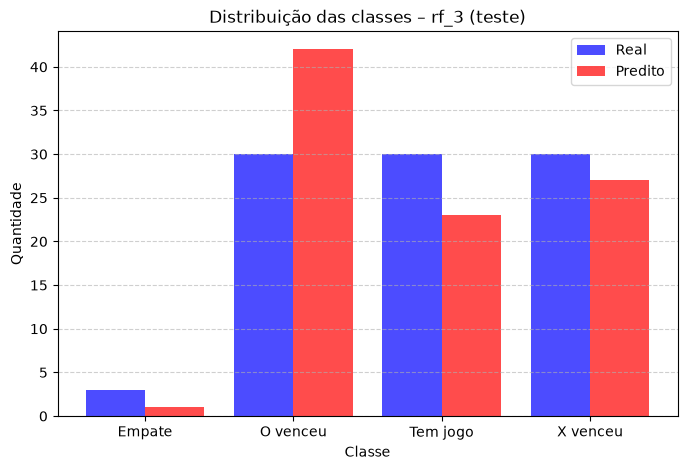

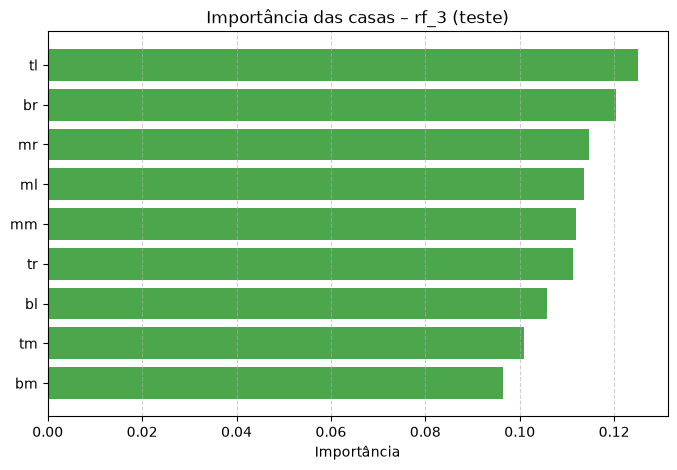

Relatório – rf_3 (teste)
              precision    recall  f1-score   support

      Empate       0.00      0.00      0.00         3
    O venceu       0.67      0.93      0.78        30
    Tem jogo       0.74      0.57      0.64        30
    X venceu       0.93      0.83      0.88        30

    accuracy                           0.75        93
   macro avg       0.58      0.58      0.57        93
weighted avg       0.75      0.75      0.74        93

Número de árvores: 200
Profundidade máxima: None
Profundidade média real das árvores: 11.235


In [15]:
# Avaliação final no TESTE
modelo_final = modelos[melhor]
y_pred_teste = modelo_final.predict(x_teste)

resultado_teste = {
    'acuracia': accuracy_score(y_teste, y_pred_teste),
    'precisao': precision_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'recall':   recall_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'f1':       f1_score(y_teste, y_pred_teste, average='macro', zero_division=0),
}

print('-----')
print(f'Resultado final no teste – {melhor}')
print(pd.Series(resultado_teste).round(4))
print('-----')

graficos(melhor, y_teste, y_pred_teste, 'teste')

### 4.4 Análise dos resultados

*(a escrever)*

## 5. Conclusão

*(a escrever)*